# NFL Salary Cap Analysis
## Contract Value Analysis

This notebook analyzes which players and positions provide the most value relative to their contract cost. We examine the most overpaid and underpaid players historically, how contract value changes across the length of a deal, and which contract structures produce the best cap efficiency.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [4]:
%pip install pyarrow numpy==1.26.4 --prefer-binary

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 25.7 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.7 MB/s  0:00:006m0:00:0100:01
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━ 0/2 [pyarrow]
    Found existing installation: numpy 2.4.6 0/2 [pyarrow]
    Uninstalling numpy-2.4.6:╺━━━━━━━━━━━━━━━━━━━ 1/2 [numpy]
      Successfully uninstalled numpy-2.4.6m━━━━━━━━━━━━━━━━━━━ 1/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numpy]32m1/2 [numpy]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

cap_eff = pd.read_parquet(os.path.join(processed_path, "cap_efficiency.parquet"), engine='pyarrow')
contracts = pd.read_parquet(os.path.join(processed_path, "contracts_modern.parquet"), engine='pyarrow')

print(f"Cap efficiency dataset: {cap_eff.shape}")
print(f"Contracts dataset: {contracts.shape}")
print(f"\nPosition groups in cap efficiency:")
print(cap_eff['position_group'].value_counts())

Cap efficiency dataset: (5783, 74)
Contracts dataset: (46608, 26)

Position groups in cap efficiency:
position_group
WR    2420
RB    1604
TE    1139
QB     614
CB       5
S        1
Name: count, dtype: int64


Data loaded successfully. The offensive cap efficiency dataset covers 5,783 player-seasons across WR, RB, TE, QB, with CB and S having minimal coverage due to the EPA data limitation noted in notebook 01.

---

### EPA Per Million by Position
Which positions generate the most value per dollar spent?

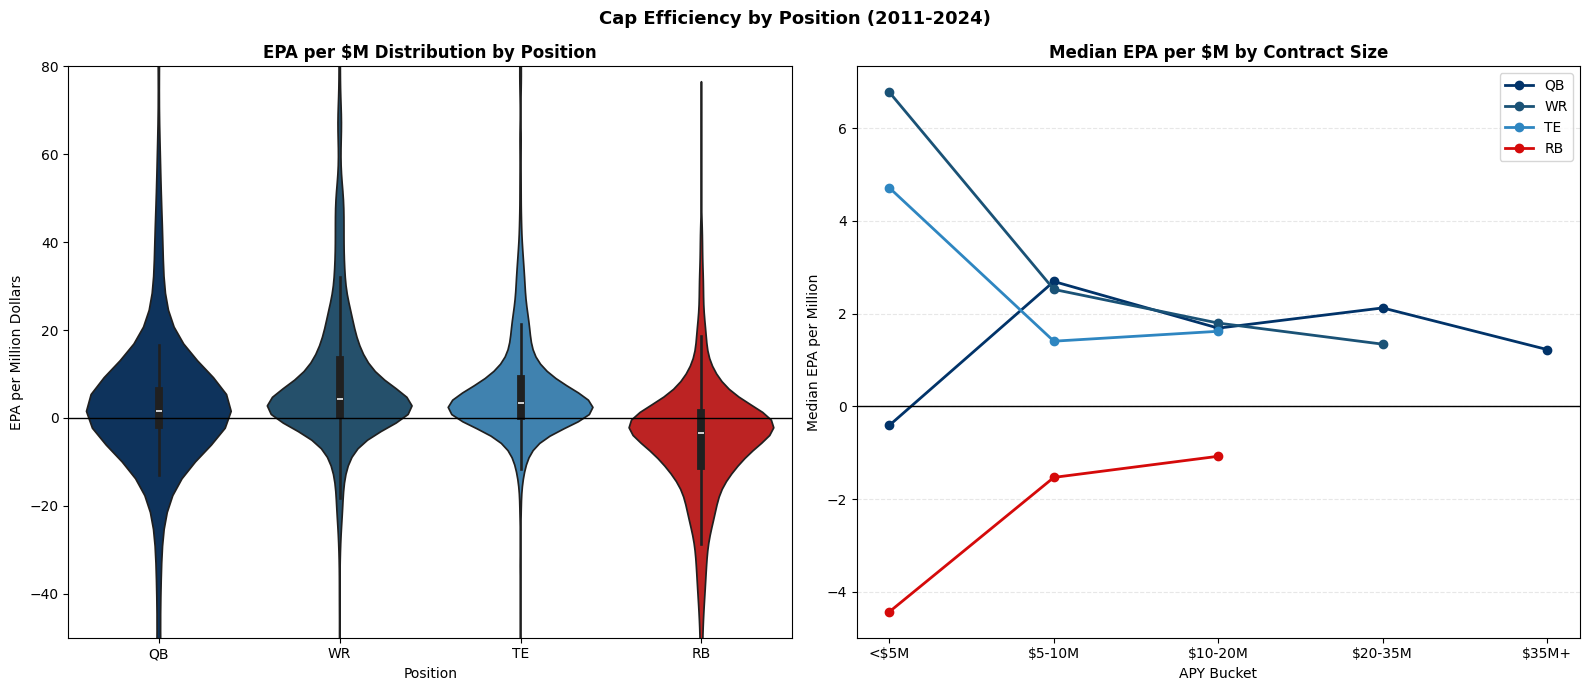

Median EPA per million by position and contract size:
position_group    QB    RB    TE    WR
apy_bucket                            
<$5M           -0.41 -4.43  4.71  6.78
$5-10M          2.69 -1.53  1.41  2.52
$10-20M         1.69 -1.08  1.62  1.80
$20-35M         2.12   NaN   NaN  1.34
$35M+           1.23   NaN   NaN   NaN


In [3]:
# EPA per million by position group - violin plot
positions_order = ['QB', 'WR', 'TE', 'RB']
plot_data = cap_eff[cap_eff['position_group'].isin(positions_order)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Violin plot
sns.violinplot(data=plot_data, x='position_group', y='epa_per_million',
               order=positions_order, hue='position_group',
               palette={'QB': '#013369', 'WR': '#1a5276', 
                        'TE': '#2e86c1', 'RB': '#D50A0A'},
               legend=False, ax=axes[0])
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('EPA per $M Distribution by Position', fontweight='bold')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('EPA per Million Dollars')
axes[0].set_ylim(-50, 80)

# Median EPA per million by position and APY bucket
plot_data['apy_bucket'] = pd.cut(plot_data['apy'],
                                  bins=[0, 5, 10, 20, 35, 100],
                                  labels=['<$5M', '$5-10M', '$10-20M', '$20-35M', '$35M+'])

bucket_eff = plot_data.groupby(['position_group', 'apy_bucket'], observed=True).agg(
    median_epa_per_m=('epa_per_million', 'median'),
    count=('epa_per_million', 'count')
).reset_index()

for pos, color in zip(positions_order, ['#013369', '#1a5276', '#2e86c1', '#D50A0A']):
    data = bucket_eff[bucket_eff['position_group'] == pos]
    axes[1].plot(data['apy_bucket'], data['median_epa_per_m'],
                 marker='o', linewidth=2, color=color, label=pos)

axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Median EPA per $M by Contract Size', fontweight='bold')
axes[1].set_xlabel('APY Bucket')
axes[1].set_ylabel('Median EPA per Million')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Cap Efficiency by Position (2011-2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "epa_per_million_by_position.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Median EPA per million by position and contract size:")
print(bucket_eff.pivot(index='apy_bucket', columns='position_group',
                        values='median_epa_per_m').round(2).to_string())

![EPA per Million by Position](../outputs/figures/epa_per_million_by_position.png)

The cap efficiency charts reveal some of the most important findings in the project:

**Violin plot (left):**
- **QB** — the widest distribution, from -40 to +80 EPA per million. Elite QBs on rookie deals generate extraordinary value; aging veterans on massive contracts drag the average down
- **WR** — right-skewed positive distribution, most WRs generate positive EPA per dollar
- **TE** — similar to WR but slightly narrower, tight ends are generally good cap value
- **RB** — centered below zero, confirming that running backs as a group generate negative cap value relative to their contracts

**Contract size vs efficiency (right):**
- **WR and TE under $5M** are extraordinarily efficient (+6.78 and +4.71) — cheap receivers on rookie deals are the best value in football
- **RB is negative at every price point** — even cheap RBs under $5M generate -4.43 EPA per million, the worst of any position at any price
- **QB efficiency peaks at $5-10M** — the sweet spot for QB value, likely veteran backup QBs and late-career starters on team-friendly deals
- **All positions decline in efficiency as contracts get larger** — the market consistently overpays for proven veterans

---

### Most Overpaid and Underpaid Players
Which specific players generated the most and least value relative to their contracts?

In [4]:
# Career cap efficiency by player
player_eff = cap_eff.groupby(['player', 'position_group']).agg(
    seasons=('season', 'nunique'),
    total_epa=('total_epa', 'sum'),
    avg_apy=('apy', 'mean'),
    avg_epa_per_m=('epa_per_million', 'mean'),
    total_games=('games', 'sum')
).reset_index()

# Filter to players with 3+ seasons and $3M+ avg APY
significant = player_eff[
    (player_eff['seasons'] >= 3) &
    (player_eff['avg_apy'] >= 3.0)
].copy()

print(f"Significant players (3+ seasons, $3M+ APY): {len(significant)}")

# Most underpaid (highest EPA per million)
print("\nMost underpaid players (highest EPA per $M):")
print(significant.nlargest(15, 'avg_epa_per_m')[
    ['player', 'position_group', 'seasons', 'avg_apy', 'total_epa', 'avg_epa_per_m']
].round(2).to_string(index=False))

print("\nMost overpaid players (lowest EPA per $M):")
print(significant.nsmallest(15, 'avg_epa_per_m')[
    ['player', 'position_group', 'seasons', 'avg_apy', 'total_epa', 'avg_epa_per_m']
].round(2).to_string(index=False))

Significant players (3+ seasons, $3M+ APY): 284

Most underpaid players (highest EPA per $M):
           player position_group  seasons  avg_apy  total_epa  avg_epa_per_m
Amon-Ra St. Brown             WR        4     6.85     384.76          54.53
     Dak Prescott             QB        8    25.41     662.24          47.67
      Tyreek Hill             WR        9    15.02     765.94          36.45
     Allen Lazard             WR        6     3.16     271.23          33.14
     Chris Godwin             WR        7     8.45     381.06          32.98
     Tyrod Taylor             QB        4     7.58     314.89          32.92
      Jalen Hurts             QB        5    15.65     508.66          32.72
   Michael Thomas             WR        5     7.66     396.45          31.58
    George Kittle             TE        8     7.84     433.00          31.27
      Josh McCown             QB        4     3.20     276.23          31.19
   Russell Wilson             QB       13    22.97     877.

The overpaid and underpaid player lists deliver some of the most compelling findings in the project:

**Most underpaid players (highest EPA per $M):**
- **Amon-Ra St. Brown (+54.53 EPA per $M)** — the most underpaid player in the dataset, generating extraordinary receiving value on a relatively modest contract
- **Dak Prescott (+47.67 EPA per $M)** — despite his large contract, his elite EPA production makes him one of the best QB values in the league
- **Tyreek Hill (+36.45 EPA per $M)** — 9 seasons of elite production across multiple contracts, consistently underpaid relative to output
- **George Kittle (+31.27 EPA per $M)** — the most underpaid TE in the dataset, his blocking and receiving value exceed his contract by a wide margin
- **Russell Wilson (+29.73 EPA per $M)** — across 13 seasons, his career EPA production significantly exceeded his contract cost

**Most overpaid players (lowest EPA per $M):**
- **The entire RB position dominates the bottom** — Arian Foster, Frank Gore, David Johnson, Josh Jacobs, Travis Etienne — every player in the bottom 15 is either an RB or a struggling backup QB
- **Frank Gore (-10.63 EPA per $M across 10 seasons)** — the most sustained negative cap value in the dataset, confirming that aging RBs on veteran contracts are the worst cap investment in football
- **Brian Hoyer (-5.96)** — the only non-RB in the bottom 15, backup QBs on veteran contracts generate negative value

---

### Visualize Overpaid vs Underpaid

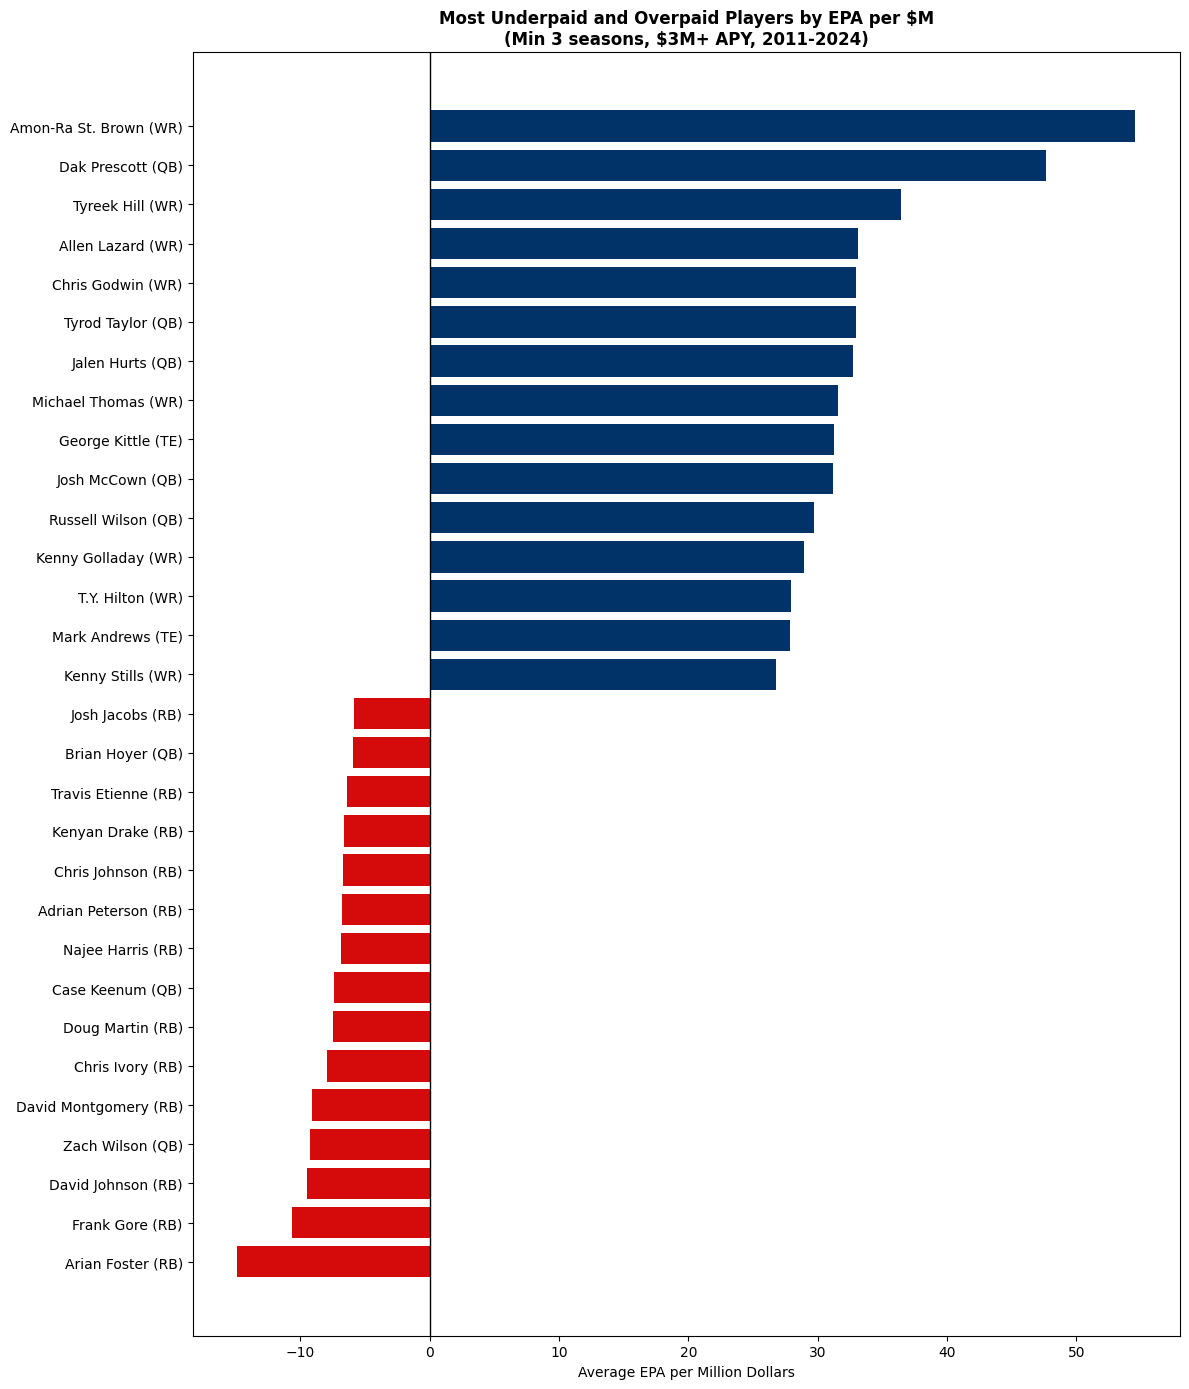

In [5]:
# Visualization - top and bottom players by EPA per million
top_players = significant.nlargest(15, 'avg_epa_per_m')
bot_players = significant.nsmallest(15, 'avg_epa_per_m')
plot_players = pd.concat([top_players, bot_players]).sort_values('avg_epa_per_m')

colors = ['#013369' if x > 0 else '#D50A0A' for x in plot_players['avg_epa_per_m']]

plt.figure(figsize=(12, 14))
bars = plt.barh(
    plot_players['player'] + ' (' + plot_players['position_group'] + ')',
    plot_players['avg_epa_per_m'],
    color=colors
)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Most Underpaid and Overpaid Players by EPA per $M\n(Min 3 seasons, $3M+ APY, 2011-2024)',
          fontsize=12, fontweight='bold')
plt.xlabel('Average EPA per Million Dollars')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "overpaid_underpaid_players.png"), dpi=150, bbox_inches='tight')
plt.show()

![Overpaid vs Underpaid Players](../outputs/figures/overpaid_underpaid_players.png)

The chart is one of the most striking in the project — a clean separation between blue (underpaid) and red (overpaid) with almost no overlap between positions. Nearly every underpaid player is a WR, TE, or QB. Nearly every overpaid player is an RB.

The RB dominance in the overpaid category is not a fluke — it reflects a fundamental market inefficiency where teams historically paid running backs like skill position stars despite rushing EPA consistently being the most replaceable offensive contribution.

---

### Contract Value Over Time
How has cap efficiency changed as contracts have grown?

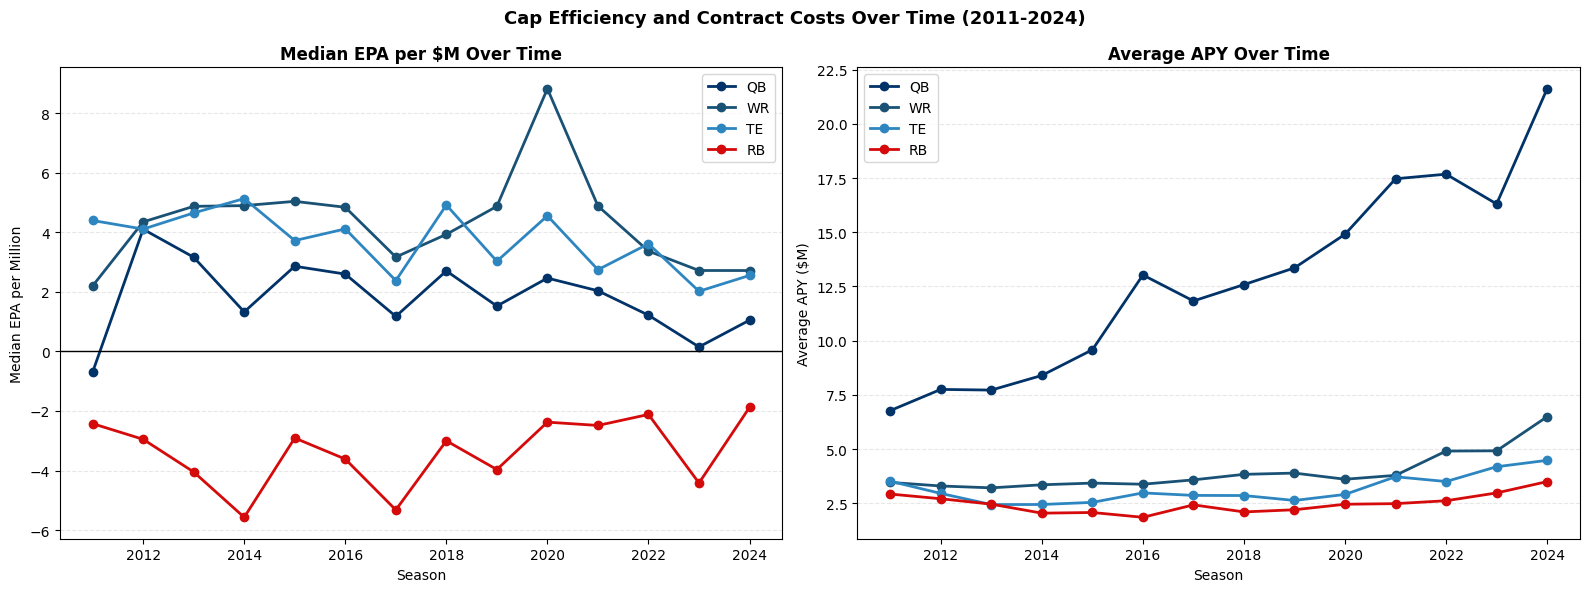

In [6]:
# Cap efficiency trend over time by position
time_eff = cap_eff[cap_eff['position_group'].isin(['QB', 'WR', 'TE', 'RB'])].groupby(
    ['season', 'position_group']
).agg(
    median_epa_per_m=('epa_per_million', 'median'),
    avg_apy=('apy', 'mean'),
    count=('epa_per_million', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'QB': '#013369', 'WR': '#1a5276', 'TE': '#2e86c1', 'RB': '#D50A0A'}

for pos in ['QB', 'WR', 'TE', 'RB']:
    data = time_eff[time_eff['position_group'] == pos].sort_values('season')
    axes[0].plot(data['season'], data['median_epa_per_m'],
                 marker='o', linewidth=2, color=colors[pos], label=pos)
    axes[1].plot(data['season'], data['avg_apy'],
                 marker='o', linewidth=2, color=colors[pos], label=pos)

axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_title('Median EPA per $M Over Time', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Median EPA per Million')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

axes[1].set_title('Average APY Over Time', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average APY ($M)')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Cap Efficiency and Contract Costs Over Time (2011-2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "efficiency_over_time.png"), dpi=150, bbox_inches='tight')
plt.show()

![Efficiency Over Time](../outputs/figures/efficiency_over_time.png)

The time series charts reveal two powerful trends:

**EPA per million over time (left):**
- **WR and TE efficiency has remained consistently positive** throughout the entire period — receivers reliably generate positive EPA per dollar at any point in the salary cap era
- **QB efficiency is volatile** — swings dramatically year to year based on which QBs are on what contracts, ranging from negative in 2011 to +9 in 2020
- **RB efficiency has been persistently negative** every single season since 2011 — the most consistent finding in the dataset. There is no year where paying RBs generated positive median cap value

**Average APY over time (right):**
- **QB contracts have exploded** — from $7M average APY in 2011 to $22M+ in 2024, a 3x increase
- **WR, TE contracts have grown moderately** — from $3M to $6-7M, roughly doubling
- **RB contracts have barely moved** — essentially flat from $2.5M to $3.5M, the only position where the market has not rewarded inflation

The combination of flat RB contracts and persistently negative EPA per million confirms that the NFL market has correctly identified running back as the least valuable skill position — teams have stopped paying them and the data shows why.

---

### Summary
This notebook establishes the contract value framework:

1. **WR under $5M is the best value in football** — +6.78 EPA per million, driven by rookie deals and cheap veteran contracts
2. **Amon-Ra St. Brown is the most underpaid player** — +54.53 EPA per million across 4 seasons
3. **RB generates negative cap value at every price point** — the most consistent finding across all years
4. **QB contracts have tripled since 2011** while efficiency has declined — teams are paying more for the same production
5. **The overpaid list is almost entirely RBs** — Frank Gore, Arian Foster, David Johnson, Adrian Peterson all appear